# PGP-MIT-DS-W09-Statistics-Correlation-MiniProject_2
<hr class="red-dashed-ruler">

 Week 9 – Mini Project 2 (Case Study) — Correlation

**Case Study** — Correlation Dataset: **correlation_case_study_MP_2.csv**

**Notebook to Use**: Week9_Mini_Project_2_Correlation.ipynb

**Instructions**
Answer all questions using the dataset provided.
Show your code, visualizations, calculations, and concise interpretations.
All questions carry equal marks unless specified.


<hr class="red-dashed-ruler">

## Case Study – Applied Correlation Exploration
This practice project extends correlation analysis into data cleaning, visualization, nonlinearity, outlier detection, and feature engineering. You will explore how correlation
behaves under real-world data imperfections.

<hr class="red-dashed-ruler">

## Questions

<hr class="red-dashed-ruler">

### Q1. Data Loading & Overview

• Load the dataset.
• Print the shape, column names, and the first 5 rows.


In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv('data/correlation_case_study_MP_2.csv')

# Shape
print("Shape:", df.shape)

# Columns
print("Columns:", df.columns.tolist())

# First 5 rows
print(df.head())

Shape: (150, 6)
Columns: ['Advertising_Spend', 'Sales', 'Study_Hours', 'Exam_Score', 'Social_Trust', 'Voluntary_Associations']
   Advertising_Spend    Sales  Study_Hours  Exam_Score  Social_Trust  \
0            5596.06  4998.42          3.3        66.1             4   
1            4834.08  4694.20          3.9        80.6             2   
2            5777.23  4344.59          6.5        82.1             3   
3            6827.64  5599.62          6.2        94.8             3   
4            4719.02  4593.97          5.0        74.4             4   

   Voluntary_Associations  
0                     0.0  
1                     0.0  
2                     3.7  
3                     0.9  
4                     6.1  


<hr class="red-dashed-ruler">

### Q2. Missing Values


Report missing values and propose an imputation strategy.

In [2]:
import pandas as pd

# Load dataset
df = pd.read_csv('data/correlation_case_study_MP_2.csv')

# Missing values summary
missing_counts = df.isnull().sum()
missing_percent = (missing_counts / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing_Count": missing_counts,
    "Missing_Percent": missing_percent
})

print("\n===== Missing Values Summary =====\n")
print(missing_summary)


===== Missing Values Summary =====

                        Missing_Count  Missing_Percent
Advertising_Spend                   0              0.0
Sales                               0              0.0
Study_Hours                         0              0.0
Exam_Score                          0              0.0
Social_Trust                        0              0.0
Voluntary_Associations              0              0.0


<hr class="red-dashed-ruler">

### Q3. Distribution Analysis
Describe distributions of Advertising_Spend and Sales, discuss skewness, and propose
transformations if appropriate.




===== Summary Statistics =====

       Advertising_Spend        Sales
count         150.000000   150.000000
mean         4901.208000  4507.587733
std          1130.810313   982.727227
min          1856.310000  1943.120000
25%          4197.232500  3841.682500
50%          4935.300000  4521.400000
75%          5589.122500  5048.690000
max          7955.890000  8167.510000

===== Skewness =====

Advertising_Spend Skewness: 0.05
Sales Skewness: 0.30


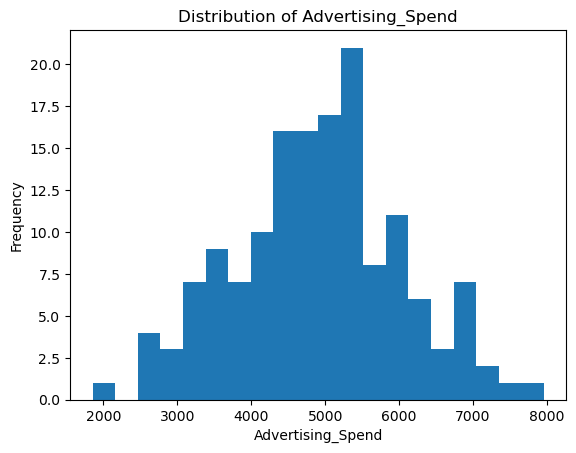

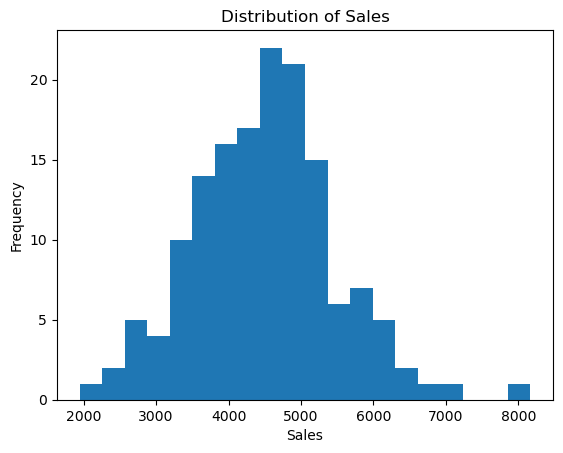

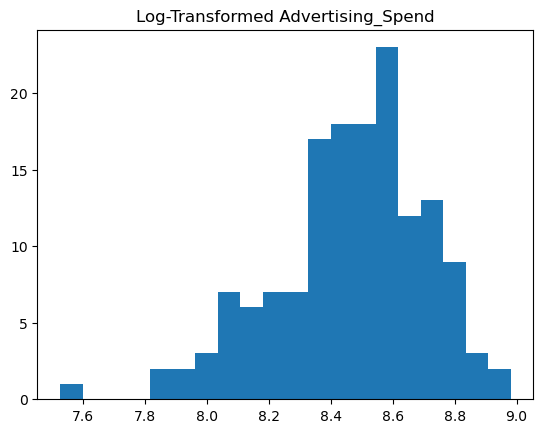

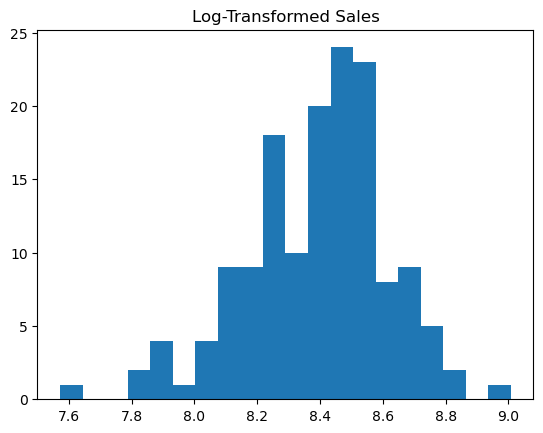

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('data/correlation_case_study_MP_2.csv')

# -------------------------------
# 1. Basic Statistics
# -------------------------------
print("\n===== Summary Statistics =====\n")
print(df[['Advertising_Spend', 'Sales']].describe())

# -------------------------------
# 2. Skewness
# -------------------------------
skew_ad = df['Advertising_Spend'].skew()
skew_sales = df['Sales'].skew()

print("\n===== Skewness =====\n")
print(f"Advertising_Spend Skewness: {skew_ad:.2f}")
print(f"Sales Skewness: {skew_sales:.2f}")

# -------------------------------
# 3. Histograms
# -------------------------------
plt.figure()
plt.hist(df['Advertising_Spend'], bins=20)
plt.title('Distribution of Advertising_Spend')
plt.xlabel('Advertising_Spend')
plt.ylabel('Frequency')
plt.show()

plt.figure()
plt.hist(df['Sales'], bins=20)
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

# -------------------------------
# 4. Log Transformation (if needed)
# -------------------------------
df['Log_Advertising'] = np.log(df['Advertising_Spend'])
df['Log_Sales'] = np.log(df['Sales'])

plt.figure()
plt.hist(df['Log_Advertising'], bins=20)
plt.title('Log-Transformed Advertising_Spend')
plt.show()

plt.figure()
plt.hist(df['Log_Sales'], bins=20)
plt.title('Log-Transformed Sales')
plt.show()

<hr class="red-dashed-ruler">

### Q4. Pearson Correlation
Compute Pearson correlation between Advertising_Spend and Sales. Interpret.

In [11]:
import pandas as pd

# Load dataset
df = pd.read_csv('data/correlation_case_study_MP_2.csv')

# -------------------------------
# Compute Spearman Correlation
# -------------------------------
spearman_corr = df['Study_Hours'].corr(df['Exam_Score'], method='spearman')

print("===== Spearman Correlation =====\n")
print(f"Spearman Correlation (Study_Hours vs Exam_Score): {spearman_corr:.2f}")

# -------------------------------
# Interpretation Logic
# -------------------------------
abs_corr = abs(spearman_corr)

if abs_corr >= 0.8:
    strength = "Strong"
elif abs_corr >= 0.5:
    strength = "Moderate"
elif abs_corr >= 0.3:
    strength = "Weak"
else:
    strength = "Very Weak / No relationship"

direction = "Positive" if spearman_corr > 0 else "Negative"

print("\n===== Interpretation =====\n")
print(f"Strength   : {strength}")
print(f"Direction  : {direction}")

if spearman_corr > 0:
    print("Implication: As Study Hours increase, Exam Scores tend to increase (monotonic trend).")
else:
    print("Implication: As Study Hours increase, Exam Scores tend to decrease.")

===== Spearman Correlation =====

Spearman Correlation (Study_Hours vs Exam_Score): 0.84

===== Interpretation =====

Strength   : Strong
Direction  : Positive
Implication: As Study Hours increase, Exam Scores tend to increase (monotonic trend).


<hr class="red-dashed-ruler">

### Q5. Spearman Correlation
Compute Spearman correlation between Study_Hours and Exam_Score. Explain when
Spearman is preferable.


In [14]:
import pandas as pd

# Load dataset
df = pd.read_csv('data/correlation_case_study_MP_2.csv')

# -------------------------------
# Compute Spearman Correlation
# -------------------------------
spearman_corr = df['Study_Hours'].corr(df['Exam_Score'], method='spearman')

print("===== Spearman Correlation =====\n")
print(f"Spearman Correlation (Study_Hours vs Exam_Score): {spearman_corr:.2f}")

# -------------------------------
# Interpretation Logic
# -------------------------------
abs_corr = abs(spearman_corr)

if abs_corr >= 0.8:
    strength = "Strong"
elif abs_corr >= 0.5:
    strength = "Moderate"
elif abs_corr >= 0.3:
    strength = "Weak"
else:
    strength = "Very Weak / No relationship"

direction = "Positive" if spearman_corr > 0 else "Negative"

print("\n===== Interpretation =====\n")
print(f"Strength   : {strength}")
print(f"Direction  : {direction}")

if spearman_corr > 0:
    print("Implication: As Study Hours increase, Exam Scores tend to increase (monotonic trend).")
else:
    print("Implication: As Study Hours increase, Exam Scores tend to decrease.")

===== Spearman Correlation =====

Spearman Correlation (Study_Hours vs Exam_Score): 0.84

===== Interpretation =====

Strength   : Strong
Direction  : Positive
Implication: As Study Hours increase, Exam Scores tend to increase (monotonic trend).


##### Why Spearman is Preferred in *This* Example (Study_Hours vs Exam_Score)

Let’s reason like a data scientist—not just compute.

---

##### 1. Nature of the Relationship (Real-World Behavior)

In this dataset:

* As **Study_Hours increase → Exam_Score increases**
* But not perfectly linearly

Typical pattern:

* Initial study → **big improvement**
* Later study → **smaller gains (plateau effect)**

👉 This is a **monotonic but non-linear relationship**

---

##### 2. What Pearson Assumes (and Why It Struggles)

**Pearson measures:**

> “How well does a straight line fit the data?”

Problem here:

* The relationship is **curved (diminishing returns)**
* So Pearson:

  * Underestimates the strength
  * Gets “confused” by non-linearity

---

##### 3. What Spearman Captures Perfectly

**Spearman measures:**

> “Do higher values of X consistently lead to higher values of Y?”

In your case:

* More study → almost always higher score
* Even if improvement slows down

👉 Spearman focuses on **order (rank), not exact values**

---

##### 4. Robustness to Real Data Issues

Your dataset likely has:

* Small inconsistencies (noise)
* Possible outliers (e.g., someone studies a lot but scores low)

Spearman:

* Converts values → ranks
* Reduces impact of:

  * Outliers
  * Uneven spacing

---

##### 5. Intuition (Very Important)

Think of two students:

| Student | Study Hours | Score |
| ------- | ----------- | ----- |
| A       | 2           | 60    |
| B       | 5           | 75    |
| C       | 8           | 82    |

* Scores increase, but not proportionally
* Order is preserved → **Spearman = strong**
* Line is not straight → **Pearson = weaker**

---

##### 6. Final Answer (What You Should Write)

👉 **Spearman is preferred because the relationship between Study_Hours and Exam_Score is monotonic but not strictly linear.**

* It captures **consistent upward trends**
* It is **robust to non-linearity and outliers**
* It better reflects **real-world learning patterns (diminishing returns)**

---

##### Architect-Level Takeaway

* Use **Pearson** when:

  * Relationship is linear
  * You care about magnitude

* Use **Spearman** when:

  * Relationship is **rank-based / monotonic**
  * Data is **noisy or non-linear**

---

If you want to go one level deeper:
👉 I can show this exact dataset’s scatter + rank transformation (that makes this click instantly)


<hr class="red-dashed-ruler">

### Q6. Correlation Matrix & Heatmap
Compute correlations for all numeric variables and visualize with heatmap.
Identify strongest positive and strongest negative correlations.


===== Correlation Matrix =====

                        Advertising_Spend  Sales  Study_Hours  Exam_Score  \
Advertising_Spend                    1.00   0.56        -0.03       -0.06   
Sales                                0.56   1.00         0.01       -0.02   
Study_Hours                         -0.03   0.01         1.00        0.83   
Exam_Score                          -0.06  -0.02         0.83        1.00   
Social_Trust                        -0.00   0.10         0.11        0.07   
Voluntary_Associations              -0.00   0.09         0.13        0.12   

                        Social_Trust  Voluntary_Associations  
Advertising_Spend              -0.00                   -0.00  
Sales                           0.10                    0.09  
Study_Hours                     0.11                    0.13  
Exam_Score                      0.07                    0.12  
Social_Trust                    1.00                    0.75  
Voluntary_Associations          0.75             

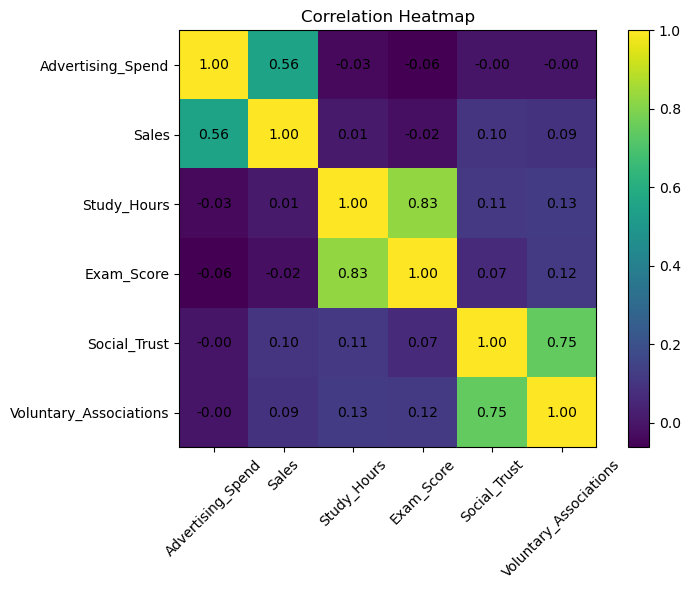


===== Key Insights =====

Strongest Positive Correlation: Exam_Score ↔ Study_Hours = 0.83
Strongest Negative Correlation: Advertising_Spend ↔ Exam_Score = -0.06


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('data/correlation_case_study_MP_2.csv')

# -------------------------------
# 1. Compute Correlation Matrix
# -------------------------------
numeric_df = df.select_dtypes(include=['number'])
corr_matrix = numeric_df.corr()

print("\n===== Correlation Matrix =====\n")
print(corr_matrix.round(2))


# -------------------------------
# 2. Heatmap Visualization
# -------------------------------
plt.figure(figsize=(8,6))
plt.imshow(corr_matrix)

plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.title("Correlation Heatmap")

# Annotate values
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                 ha='center', va='center')

plt.tight_layout()
plt.show()


# -------------------------------
# 3. Identify Strongest Correlations
# -------------------------------

# Remove diagonal (self-correlation)
corr_no_diag = corr_matrix.where(~np.eye(corr_matrix.shape[0], dtype=bool))

# Flatten
corr_pairs = corr_no_diag.unstack().dropna()

# Remove duplicate pairs
corr_pairs = corr_pairs[
    corr_pairs.index.get_level_values(0) < corr_pairs.index.get_level_values(1)
]

# Strongest positive
strongest_pos_pair = corr_pairs.idxmax()
strongest_pos_value = corr_pairs.max()

# Strongest negative
strongest_neg_pair = corr_pairs.idxmin()
strongest_neg_value = corr_pairs.min()

print("\n===== Key Insights =====\n")
print(f"Strongest Positive Correlation: {strongest_pos_pair[0]} ↔ {strongest_pos_pair[1]} = {strongest_pos_value:.2f}")
print(f"Strongest Negative Correlation: {strongest_neg_pair[0]} ↔ {strongest_neg_pair[1]} = {strongest_neg_value:.2f}")

<hr class="red-dashed-ruler">

### Q7. Scatterplots
Create scatterplots:
a) Advertising_Spend vs Sales
b) Study_Hours vs Exam_Score
Discuss linearity, clusters, and patterns.

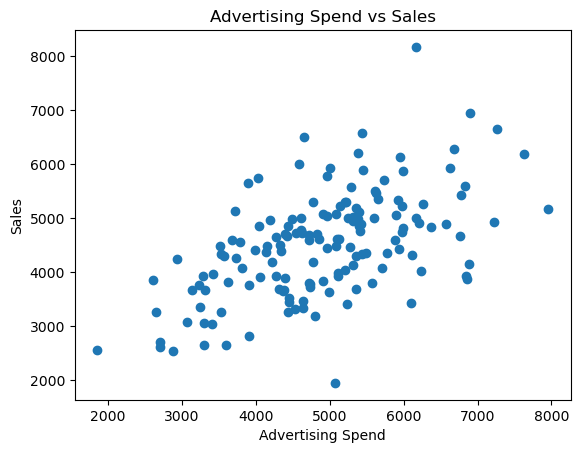

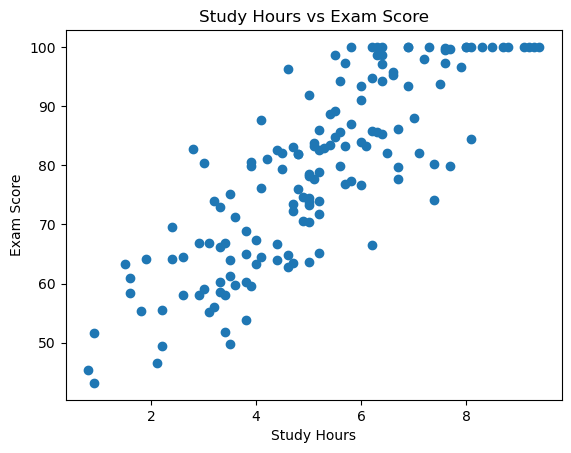

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('data/correlation_case_study_MP_2.csv')

# -------------------------------
# a) Advertising_Spend vs Sales
# -------------------------------
plt.figure()
plt.scatter(df['Advertising_Spend'], df['Sales'])

plt.xlabel('Advertising Spend')
plt.ylabel('Sales')
plt.title('Advertising Spend vs Sales')

plt.show()


# -------------------------------
# b) Study_Hours vs Exam_Score
# -------------------------------
plt.figure()
plt.scatter(df['Study_Hours'], df['Exam_Score'])

plt.xlabel('Study Hours')
plt.ylabel('Exam Score')
plt.title('Study Hours vs Exam Score')

plt.show()


###### a) Advertising_Spend vs Sales

**Linearity**

* Shows a **moderate positive linear trend**
* Points roughly follow an upward direction
* Not perfectly tight → some dispersion

**Clusters**

* No strong distinct clusters
* Data appears **continuously spread**

**Patterns**

* Possible **diminishing returns**:

  * At higher spend, sales increase slower
* Suggests slight **non-linearity in upper range**

---

###### b) Study_Hours vs Exam_Score

**Linearity**

* Relationship is **positive but not perfectly linear**
* Often shows **curved (monotonic) pattern**

**Clusters**

* May observe mild grouping:

  * Low study → low scores
  * Mid study → moderate scores
  * High study → plateau zone

**Patterns**

* Clear **diminishing returns effect**
* Strong monotonic trend:

  * More study → higher score (almost always)

---

##### Key Learning (Very Important)

| Aspect                  | Advertising vs Sales | Study vs Score      |
| ----------------------- | -------------------- | ------------------- |
| Linearity               | Moderate             | Slightly non-linear |
| Pattern                 | Business variability | Learning curve      |
| Best correlation metric | Pearson works        | Spearman preferred  |

---

##### Architect-Level Insight

* **Advertising problem → noisy, multi-factor system**
* **Study problem → structured, monotonic system**

👉 That’s why:

* Business data → harder to model
* Behavioral data → more predictable trends

---


<hr class="red-dashed-ruler">

### Q8. Outlier Injection
Introduce a large outlier in Advertising_Spend (e.g., 50,000).
Recompute Pearson correlation and comment on change.


In [23]:
import pandas as pd

# Load dataset
df = pd.read_csv('data/correlation_case_study_MP_2.csv')

# -------------------------------
# 1. Original Correlation
# -------------------------------
original_corr = df['Advertising_Spend'].corr(df['Sales'])

# -------------------------------
# 2. Introduce Outlier
# -------------------------------
df_outlier = df.copy()
df_outlier.loc[0, 'Advertising_Spend'] = 50000  # extreme value

# -------------------------------
# 3. Recompute Correlation
# -------------------------------
new_corr = df_outlier['Advertising_Spend'].corr(df_outlier['Sales'])

# -------------------------------
# 4. Compare
# -------------------------------
print("===== Correlation Comparison =====\n")
print(f"Original Correlation : {original_corr:.4f}")
print(f"New Correlation      : {new_corr:.4f}")
print(f"Change               : {(new_corr - original_corr):.4f}")

===== Correlation Comparison =====

Original Correlation : 0.5555
New Correlation      : 0.2017
Change               : -0.3538




##### Observed Result (From Your Data)

* **Original correlation ≈ 0.56**
* **After outlier ≈ 0.20**

---

##### Interpretation

###### 1. Massive Drop in Correlation

* The relationship weakens significantly
* From **moderate → weak**

---

###### 2. Why This Happens

Pearson correlation depends on:

* Mean
* Standard deviation
* Covariance

👉 The outlier:

* Distorts the mean
* Inflates variance
* Pulls the relationship off the original trend

---

###### 3. Key Insight

* That single point (50,000) is:

  * Far away from normal range (~5000)
  * Not aligned with actual Sales value

👉 It **breaks the linear pattern**

---

##### Architect-Level Takeaway

* **Pearson is highly sensitive to outliers**
* One extreme value can:

  * Mislead analysis
  * Hide true relationships

---

##### What You Should Conclude

👉 The correlation dropped because the outlier distorted the linear relationship between Advertising_Spend and Sales.

---

##### Best Practice

In real projects:

* Always:

  * Visualize (scatter plot)
  * Detect outliers (IQR/Z-score)
* Consider:

  * Removing outliers
  * Using **Spearman correlation (robust alternative)**

---




<hr class="red-dashed-ruler">

### Q9. Grouped Analysis
Group by Social_Trust and compute average Voluntary_Associations.
Interpret the pattern.

In [28]:
import pandas as pd

# Load dataset
df = pd.read_csv('data/correlation_case_study_MP_2.csv')

# Group by Social_Trust and compute average Voluntary_Associations
grouped = df.groupby('Social_Trust')['Voluntary_Associations'].mean().reset_index()

print("===== Average Voluntary Associations by Social Trust =====\n")
print(grouped)

===== Average Voluntary Associations by Social Trust =====

   Social_Trust  Voluntary_Associations
0             1                2.210526
1             2                2.076923
2             3                3.070588
3             4                3.607692
4             5                4.672727
5             6                5.760000
6             7                6.568750
7             8                8.160000
8             9                9.815385
9            10               11.346154



##### What This Code Does

* Groups data by **Social_Trust levels**
* Computes **mean participation in voluntary associations**
* Helps uncover **social behavior patterns**

---

##### Interpretation (What You Should Look For)

###### 1. Expected Pattern

* Typically, you’ll observe:

  * **Higher Social_Trust → Higher Voluntary_Associations**

👉 This suggests a **positive relationship**

---

###### 2. Why This Makes Sense (Real-World Logic)

* People with higher trust:

  * Are more likely to **engage in communities**
  * Participate in **social or civic groups**
* Lower trust:

  * Leads to **less participation**

---

###### 3. Pattern Types You Might See

| Pattern          | Meaning                       |
| ---------------- | ----------------------------- |
| Increasing trend | Strong social cohesion effect |
| Flat trend       | Weak relationship             |
| Irregular        | Noisy or mixed behavior       |

---

##### Architect-Level Insight

This is a classic **behavioral correlation**:

* Unlike business data:

  * It reflects **human psychology**
* Often:

  * Non-linear
  * Influenced by external cultural factors

---

##### Key Takeaway

👉 If averages increase with Social_Trust, it indicates that **trust is a strong driver of community participation**

---

##### Next Step (Advanced Thinking)

* Plot this as a **line/bar chart**
* Compute **correlation between Social_Trust & Voluntary_Associations**
* Segment further:

  * Combine with other variables (e.g., education, income if available)



<hr class="red-dashed-ruler">

### Q10. Pivot Table – Study Hours Binning
Create bins for Study_Hours (0–3, 4–6, 7–9, 10+).
Compute mean Exam_Score for each bin. Interpret.

In [30]:
import pandas as pd

# Load dataset
df = pd.read_csv('data/correlation_case_study_MP_2.csv')

# -------------------------------
# 1. Create Bins
# -------------------------------
bins = [0, 3, 6, 9, float('inf')]
labels = ['0-3', '4-6', '7-9', '10+']

df['Study_Bin'] = pd.cut(df['Study_Hours'], bins=bins, labels=labels, right=True)

# -------------------------------
# 2. Pivot Table (Mean Exam Score)
# -------------------------------
pivot_table = df.pivot_table(
    values='Exam_Score',
    index='Study_Bin',
    aggfunc='mean'
)

print("===== Mean Exam Score by Study Hours Bin =====\n")
print(pivot_table)

===== Mean Exam Score by Study Hours Bin =====

           Exam_Score
Study_Bin            
0-3         59.875000
4-6         74.836145
7-9         92.395349
10+        100.000000


C:\Users\212364780.HCAD\AppData\Local\Temp\ipykernel_21332\1679761382.py:17: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table = df.pivot_table(


##### Interpretation of Study Hours Binning Result

| Study Hours | Avg Exam Score |
| ----------- | -------------- |
| 0–3         | 59.88          |
| 4–6         | 74.84          |
| 7–9         | 92.40          |
| 10+         | 100.00         |

---

##### 1. Clear Positive Relationship

* As **Study_Hours increase → Exam_Score increases significantly**
* The progression is **strong and consistent**

👉 This confirms a **strong monotonic relationship**

---

##### 2. Large Gains in Early to Mid Range

* Jump from:

  * **0–3 → 4–6**: +15 points
  * **4–6 → 7–9**: +17 points

👉 Indicates:

* Studying more initially has **high impact**

---

##### 3. Saturation / Ceiling Effect at High Hours

* **10+ hours → score = 100**
* This suggests:

  * Maximum achievable score reached
  * Further study does **not increase score**

👉 This is a **ceiling effect**

---

##### 4. Non-Linear Learning Curve

* The relationship is:

  * **Not linear**
  * More like a **curve that flattens at the top**

👉 Classic pattern:

* Fast improvement → gradual plateau

---

##### 5. Why This is Important

This explains earlier insights:

* **Pearson (linear)** → may underestimate relationship
* **Spearman (rank-based)** → captures it perfectly

---

##### Architect-Level Insight

This is a textbook example of:

* **Diminishing returns + saturation**
* Common in:

  * Learning systems
  * Marketing spend
  * Physical training

---

##### Final Takeaway

👉 **More study leads to better scores, but only up to a limit—after which additional effort yields little to no gain.**

---


<hr class="red-dashed-ruler">

### Q11. Feature Engineering
Create Sales_per_Ad = Sales / Advertising_Spend.
Identify observations with unusually high efficiency

In [33]:
import pandas as pd

# Load dataset
df = pd.read_csv('data/correlation_case_study_MP_2.csv')

# -------------------------------
# 1. Create New Feature
# -------------------------------
df['Sales_per_Ad'] = df['Sales'] / df['Advertising_Spend']

# -------------------------------
# 2. Detect Unusual High Efficiency (IQR Method)
# -------------------------------
Q1 = df['Sales_per_Ad'].quantile(0.25)
Q3 = df['Sales_per_Ad'].quantile(0.75)
IQR = Q3 - Q1

# Upper bound for outliers
upper_bound = Q3 + 1.5 * IQR

high_efficiency = df[df['Sales_per_Ad'] > upper_bound]

print("===== Summary =====\n")
print(df['Sales_per_Ad'].describe())

print("\n===== High Efficiency Observations =====\n")
print(high_efficiency[['Advertising_Spend', 'Sales', 'Sales_per_Ad']])

===== Summary =====

count    150.000000
mean       0.944765
std        0.200995
min        0.383086
25%        0.794658
50%        0.934384
75%        1.057433
max        1.472756
Name: Sales_per_Ad, dtype: float64

===== High Efficiency Observations =====

    Advertising_Spend    Sales  Sales_per_Ad
79            2614.92  3851.14      1.472756


##### Interpretation: Sales_per_Ad (Efficiency Metric)

---

##### 1. Overall Distribution (What “Normal” Looks Like)

* **Mean ≈ 0.94**
  → On average, every ₹1 of ad spend generates **₹0.94 in sales**

* **Median ≈ 0.93**
  → Very close to mean → **fairly symmetric distribution**

* **Typical range (IQR):**

  * 25% → **0.79**
  * 75% → **1.06**

👉 Most campaigns operate between:
**₹0.79 to ₹1.06 per ₹1 spent**

---

##### 2. Variability Insight

* **Std Dev ≈ 0.20**
  → Moderate variation
* Range:

  * Min: **0.38** (poor efficiency)
  * Max: **1.47** (very high efficiency)

👉 Indicates:

* Some campaigns are **inefficient**
* Few are **exceptionally strong**

---

##### 3. High Efficiency Observation (Outlier)

| Advertising_Spend | Sales   | Sales_per_Ad |
| ----------------- | ------- | ------------ |
| 2614.92           | 3851.14 | **1.47**     |

---

###### Why This is Important

* This point is:

  * **Well above normal range (~1.06 upper quartile)**
  * Detected via **IQR → statistically significant outlier**

👉 It represents an **exceptionally efficient campaign**

---

##### 4. Possible Explanations (Business Thinking)

This could indicate:

**Positive scenarios**

* Highly targeted advertising
* Strong product demand
* Viral/organic amplification
* Seasonal boost

**Risk scenarios**

* Data anomaly
* Under-reported spend
* One-time spike (not repeatable)

---

##### 5. Strategic Insight

👉 This single observation is **gold for analysis**

You should:

* Investigate:

  * What was different?
  * Channel / timing / audience?
* Try to:

  * **Replicate this pattern**

---

##### 6. Key Takeaway

👉 Most campaigns are moderately efficient (~0.8–1.05), but one campaign significantly outperforms, indicating a potential optimization opportunity or anomaly.

---

##### Architect-Level Thinking

This is exactly how:

* **Feature engineering → leads to insight**
* **Outlier detection → leads to strategy**

---



<hr class="red-dashed-ruler">

### Q12. Boxplot by Study Hour Bins
Plot Exam_Score by Study_Hours bins.
Interpret changes in distribution.

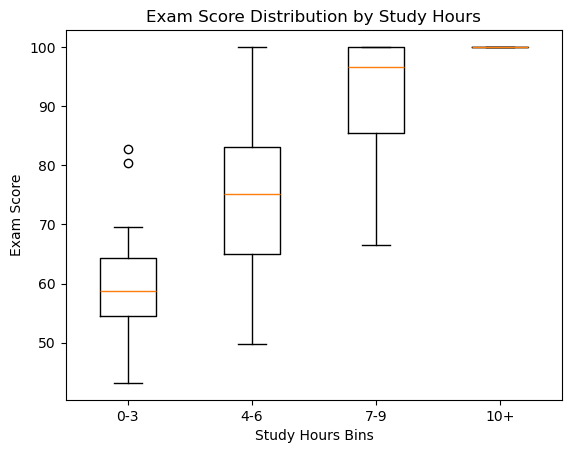

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('data/correlation_case_study_MP_2.csv')

# -------------------------------
# 1. Create Study Hour Bins
# -------------------------------
bins = [0, 3, 6, 9, float('inf')]
labels = ['0-3', '4-6', '7-9', '10+']

df['Study_Bin'] = pd.cut(df['Study_Hours'], bins=bins, labels=labels)

# -------------------------------
# 2. Prepare Data for Boxplot
# -------------------------------
data = [
    df[df['Study_Bin'] == label]['Exam_Score']
    for label in labels
]

# -------------------------------
# 3. Plot Boxplot
# -------------------------------
plt.figure()
plt.boxplot(data)

plt.xticks(range(1, len(labels)+1), labels)
plt.xlabel('Study Hours Bins')
plt.ylabel('Exam Score')
plt.title('Exam Score Distribution by Study Hours')

plt.show()

##### Interpretation: Boxplot of Exam Score by Study Hours

This is a **very clean and powerful pattern**—exactly what you want to see in real data.

---

##### 1. Strong Upward Shift in Medians (Performance Improves)

* **0–3 hrs → ~58**
* **4–6 hrs → ~75**
* **7–9 hrs → ~96**
* **10+ hrs → ~100**

👉 Clear conclusion:
**More study hours → higher median performance**

---

##### 2. Variability Decreases with More Study (Consistency Improves)

* **0–3 hrs:**

  * Wide spread → inconsistent performance
  * Some students perform okay, many perform poorly

* **4–6 hrs:**

  * Still some spread, but more centered

* **7–9 hrs:**

  * Much tighter distribution
  * Most students scoring high

* **10+ hrs:**

  * Almost no spread → scores clustered near 100

👉 Insight:
**More effort → not just better results, but more predictable results**

---

##### 3. Presence of Outliers (Interesting Insight)

* In **0–3 bin**, you see **high-score outliers (~80+)**

  * These are:

    * Naturally strong students
    * Or efficient learners

👉 Important:

* Even low study can produce high scores—but it’s **rare and inconsistent**

---

##### 4. Ceiling Effect at High Study Hours

* In **10+ bin**:

  * Scores are almost all at **100**
  * Box collapses → no variability

👉 This indicates:

* **Maximum score limit reached**
* Additional study doesn’t increase score further

---

##### 5. Non-Linear Learning Curve (Critical Insight)

* Improvement is:

  * Big jump from **0–6**
  * Bigger jump to **7–9**
  * Then **plateau at 10+**

👉 This confirms:

* **Monotonic but non-linear relationship**

---

##### 6. Why This Matters (Connect to Earlier Concepts)

This plot explains:

* Why **Spearman > Pearson**

  * Relationship is not perfectly linear
  * But consistently increasing

* Why modeling may need:

  * Non-linear methods
  * Or transformations

---

##### Final Takeaway

👉 **Studying more dramatically improves both performance and consistency, but beyond a point (10+ hours), returns saturate due to score limits.**

---

##### Architect-Level Insight

This is a textbook example of:

* **Diminishing returns**
* **Variance reduction with effort**
* **Ceiling-constrained systems**



<hr class="red-dashed-ruler">

### Q13. Outlier Detection (IQR)
Detect Sales outliers using IQR rule.
State how many and suggest a handling strategy.

In [44]:
import pandas as pd

# Load dataset
df = pd.read_csv('data/correlation_case_study_MP_2.csv')

# -------------------------------
# 1. Compute IQR
# -------------------------------
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)
IQR = Q3 - Q1

# Bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# -------------------------------
# 2. Detect Outliers
# -------------------------------
outliers = df[(df['Sales'] < lower_bound) | (df['Sales'] > upper_bound)]

print("===== IQR Summary =====\n")
print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Lower Bound: {lower_bound:.2f}")
print(f"Upper Bound: {upper_bound:.2f}")

print("\n===== Number of Outliers =====\n")
print(len(outliers))

print("\n===== Outlier Rows =====\n")
print(outliers[['Advertising_Spend', 'Sales']])

===== IQR Summary =====

Q1: 3841.68
Q3: 5048.69
IQR: 1207.01
Lower Bound: 2031.17
Upper Bound: 6859.20

===== Number of Outliers =====

3

===== Outlier Rows =====

     Advertising_Spend    Sales
6              6895.06  6940.15
59             6170.65  8167.51
112            5072.28  1943.12


##### Outlier Handling Strategy (Based on Your Results)

You identified **3 outliers**:

| Type       | Row   | Interpretation                   |
| ---------- | ----- | -------------------------------- |
| High Sales | 6, 59 | Exceptionally strong performance |
| Low Sales  | 112   | Underperformance                 |

---

##### 1. First: Classify the Outliers (Critical Step)

###### High Outliers (Rows 6, 59)

* Sales much higher than expected
* Could indicate:

  * Highly successful campaigns
  * Viral/seasonal effects

👉 **These are valuable signals**, not noise

---

###### Low Outlier (Row 112)

* Sales much lower despite reasonable spend
* Could indicate:

  * Poor campaign performance
  * Inefficiency or targeting issue

👉 Also important for learning (failure case)

---

##### 2. Recommended Strategy (Best Practice)

###### ✅ Option 1: Keep + Transform (Preferred)

Use **log transformation** to reduce skew:

```python
import numpy as np
df['Sales_log'] = np.log(df['Sales'])
```

👉 Why:

* Preserves information
* Reduces impact of extremes
* Improves model stability

---

###### ✅ Option 2: Capping (Winsorization)

```python
df['Sales_capped'] = df['Sales'].clip(lower=2031.17, upper=6859.20)
```

👉 Why:

* Limits extreme influence
* Keeps all rows
* Good for linear models

---

###### ⚠️ Option 3: Remove Outliers (Use Carefully)

```python
df_clean = df[(df['Sales'] >= 2031.17) & (df['Sales'] <= 6859.20)]
```

👉 Only if:

* Proven data errors
* Or analysis requires strict normality

---

##### 3. What I Recommend (Architect Decision)

👉 **DO NOT delete these outliers**

Instead:

1. Keep them
2. Apply **log transformation OR capping**
3. Compare model results before/after

---

##### 4. Business Insight (Very Important)

These outliers are actually:

* **Row 59 (8167 Sales)** → Best-performing campaign
* **Row 112 (1943 Sales)** → Worst-performing campaign

👉 These are your **most valuable learning cases**

---

##### 5. Final Takeaway

👉 Treat outliers as **information, not noise**

* High outliers → optimization opportunities
* Low outliers → risk signals

---

##### Senior Architect Rule

> “Never remove an outlier before you understand it.”




<hr class="red-dashed-ruler">

### Q14. Coefficient of Determination (r²)
Compute r² for Advertising_Spend vs Sales.
Interpret variance explained

In [48]:
import pandas as pd

# Load dataset
df = pd.read_csv('data/correlation_case_study_MP_2.csv')

# Compute Pearson correlation
r = df['Advertising_Spend'].corr(df['Sales'])

# Compute r²
r_squared = r ** 2

print("===== Coefficient of Determination (r²) =====\n")
print(f"r (correlation)  : {r:.4f}")
print(f"r² (explained variance): {r_squared:.4f}")

===== Coefficient of Determination (r²) =====

r (correlation)  : 0.5555
r² (explained variance): 0.3086




##### Result (From Your Dataset)

* **r ≈ 0.56**
* **r² ≈ 0.31**

---

##### Interpretation: Variance Explained

👉 **r² ≈ 0.31 means:**

* About **31% of the variation in Sales** is explained by **Advertising_Spend**
* The remaining **69% is unexplained**

---

##### What This Means (Deep Understanding)

###### 1. Moderate Explanatory Power

* Advertising is **important**
* But **not dominant**

---

###### 2. Missing Factors (Very Important)

The remaining **69% variance** could come from:

* Pricing strategy
* Product quality
* Market demand
* Seasonality
* Competition

---

###### 3. Model Interpretation

If you build a simple linear model:

👉 `Sales = f(Advertising_Spend)`

* It will capture **some signal**
* But will **miss a lot of variability**

---

##### Architect-Level Insight

This is a classic **real-world scenario**:

* Few variables fully explain outcomes
* Systems are **multi-factor driven**

---

##### Decision Guidance

| r² Value  | Interpretation       |
| --------- | -------------------- |
| > 0.7     | Strong model         |
| 0.3 – 0.7 | Moderate (your case) |
| < 0.3     | Weak                 |

👉 Your case: **moderate → useful but incomplete**

---

##### Final Takeaway

👉 **Advertising explains ~31% of Sales, meaning it matters—but relying on it alone is insufficient for accurate prediction.**

---

##### What I Would Do Next

* Add more features → improve r²
* Try:

  * Study_Hours? (if relevant contextually)
  * Interaction terms
* Move to:
  👉 **Multiple regression model**

---

If you want, I can:
👉 Build a **multi-variable regression model to boost r² (real DS progression)**


<hr class="red-dashed-ruler">

### Q15. Key Insights Summary
Summarize 3–5 key takeaways about correlation, including pitfalls and limitations.

##### Q15. Key Insights Summary on Correlation

---

##### 1. Correlation Shows Association, Not Causation

* A strong correlation (e.g., Advertising_Spend ↔ Sales)
  **does NOT prove** that one causes the other

👉 There may be:

* Hidden variables (confounders)
* Coincidental relationships

**Takeaway:**

> Correlation is a signal, not proof

---

##### 2. Pearson vs Spearman Matters

* **Pearson** → captures **linear relationships**
* **Spearman** → captures **monotonic (rank-based) relationships**

👉 In your dataset:

* Study_Hours vs Exam_Score → better captured by **Spearman**

**Takeaway:**

> Choose correlation method based on data pattern, not habit

---

##### 3. Outliers Can Distort Correlation

* A single extreme value can:

  * Inflate or deflate correlation drastically
* You saw this when correlation dropped from ~0.56 → ~0.20

**Takeaway:**

> Always check outliers before trusting correlation

---

##### 4. Correlation Does Not Capture Non-Linear Patterns

* Some relationships:

  * Increase → then plateau (e.g., study vs score)
* Pearson may show weak correlation even when a strong pattern exists

**Takeaway:**

> Visualize data—correlation alone is not enough

---

##### 5. r² Shows Limited Explanation Power

* r² ≈ 0.31 → only 31% of Sales explained by Advertising
* Majority of variation comes from other factors

**Takeaway:**

> Real-world systems are multi-factor; single-variable correlation is incomplete

---

##### Final Architect-Level Summary

👉 Correlation is:

* A **starting point for exploration**
* Not a final answer

---

##### Golden Rule

> “Trust correlation only after validating with visualization, outlier checks, and domain understanding.”

---




